# DL multietiqueta preliminar con volumenes 3D y mascaras

Notebook preliminar para probar rapidamente varias configuraciones de deep learning basadas solo en imagen 3D y mascaras.

Objetivo de este notebook:
- comparar varios preprocesados ya disponibles en `ngpu`
- comparar varias combinaciones de mascaras
- monitorizar la evolucion de la perdida y de las metricas por epoca
- guardar artefactos intermedios para decidir despues que variantes merecen pasar a un script final reproducible

Este notebook **no es la evaluacion final** del TFM. Esta pensado como bloque preliminar para exploracion controlada.

## Diseno actual del notebook

Endpoint multietiqueta principal:
- `Hemorragia`
- `Neumotórax`
- `Sin_complicacion` derivada

Por defecto se excluyen los pacientes cuya unica complicacion es un evento fuera del endpoint principal, como `Derrame pleural`, para evitar incoherencias semanticas.

Experimentos iniciales incluidos:
- `lung_only_masked_ct`
- `nodule_only_masked_ct`
- `ct_lung_nodule`
- `nodule_vessels`
- `ct_lung_nodule_vessels`
- `weighted_lung_nodule_vessels`

Preprocesados por defecto:
- `resize_cube64_hu_m300_1400`
- `resize_cube64_hu_m600_1500`
- `resize_cube128_hu_m300_1400`
- `resize_cube128_hu_m600_1500`

Se han dejado fuera por defecto los `multiwindowing_separadas`, porque en este proyecto han dado problemas especificos de formato 4D y no son la mejor opcion para un preliminar rapido.

In [1]:
from pathlib import Path
import json
import math
import random
import time
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.cuda.amp import GradScaler, autocast

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    hamming_loss,
    jaccard_score,
)

from monai.networks.nets import resnet18
from monai.transforms import Compose, RandFlip, RandRotate90, RandAffine, EnsureType

print("Torch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Matplotlib is building the font cache; this may take a moment.
2026-07-09 11:04:30.462094: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783595072.826533 1664564 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783595073.544747 1664564 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1783595079.172519 1664564 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783595079.172574 1664564 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783595079.1

Torch: 2.5.1+cu124
CUDA disponible: True
GPU: Tesla V100-SXM2-32GB


In [2]:
PROJECT_ROOT = Path("/mnt/homeGPU/mcribilles/tfm")
CLINICAL_CSV = PROJECT_ROOT / "clinical_data/210pacientes/clinical_data.csv"
PREPROC_ROOT = PROJECT_ROOT / "volumenes_preprocesados"
NOTEBOOK_OUTPUT_ROOT = PROJECT_ROOT / "codigo/DL_multietiqueta/outputs_preliminar"
NOTEBOOK_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

TARGET_LABELS = ["Hemorragia", "Neumotórax", "Sin_complicacion"]
DROP_OFF_TARGET_ONLY = True

PREPROCESSINGS = [
    "resize_cube64_hu_m300_1400",
    "resize_cube64_hu_m600_1500",
    "resize_cube128_hu_m300_1400",
    "resize_cube128_hu_m600_1500",
]

EXPERIMENTS = [
    {
        "name": "lung_only_masked_ct",
        "channels": ["ct_lung"],
        "description": "Solo imagen dentro del pulmon",
    },
    {
        "name": "nodule_only_masked_ct",
        "channels": ["ct_nodule"],
        "description": "Solo imagen dentro del nodulo",
    },
    {
        "name": "ct_lung_nodule",
        "channels": ["ct_lung", "lung", "nodule"],
        "description": "Imagen pulmonar + mascara pulmon + mascara nodulo",
    },
    {
        "name": "nodule_vessels",
        "channels": ["ct_nodule", "nodule", "vessels"],
        "description": "Imagen del nodulo + mascara nodulo + mascara vasos",
    },
    {
        "name": "ct_lung_nodule_vessels",
        "channels": ["ct_lung", "lung", "nodule", "vessels"],
        "description": "Imagen pulmonar + pulmon + nodulo + vasos",
    },
    {
        "name": "weighted_lung_nodule_vessels",
        "channels": ["weighted_ct"],
        "weights": {"lung": 0.25, "nodule": 1.00, "vessels": 0.75},
        "description": "Canal unico con ponderacion pulmon-nodulo-vasos",
    },
]

REQUIRE_COMMON_COHORT = True
MAX_EXPERIMENTS = None
MAX_PREPROCS = None

TRAIN_SIZE = 0.80
RANDOM_SEED = 42
BATCH_SIZE = 4
MAX_EPOCHS = 35
PATIENCE = 8
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
DROPOUT = 0.30
NUM_WORKERS = 4
VAL_THRESHOLD = 0.5
USE_AMP = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RUN_TAG = datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_ROOT = NOTEBOOK_OUTPUT_ROOT / f"run_preliminar_{RUN_TAG}"
RUN_ROOT.mkdir(parents=True, exist_ok=True)

print("RUN_ROOT:", RUN_ROOT)
print("DEVICE:", DEVICE)

RUN_ROOT: /mnt/homeGPU/mcribilles/tfm/codigo/DL_multietiqueta/outputs_preliminar/run_preliminar_20260709_110921
DEVICE: cuda


In [3]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(RANDOM_SEED)

In [4]:
def normalize_text(x):
    if pd.isna(x):
        return ""
    return str(x).strip()

def split_complications(raw_value: str):
    value = normalize_text(raw_value)
    if value == "" or value.lower() == "x":
        return []
    parts = [p.strip() for p in value.split(",")]
    return [p for p in parts if p]

def build_multilabel_dataframe(clinical_csv: Path):
    df = pd.read_csv(clinical_csv)
    df = df.copy()
    df["patient_id"] = df["patient_id"].astype(str)
    df["Complicación"] = df["Complicación"].apply(normalize_text)
    df["Tipo de complicación"] = df["Tipo de complicación"].apply(normalize_text)

    parsed = df["Tipo de complicación"].apply(split_complications)
    df["Hemorragia"] = parsed.apply(lambda xs: int("Hemorragia" in xs))
    df["Neumotórax"] = parsed.apply(lambda xs: int("Neumotórax" in xs))
    df["Derrame_pleural"] = parsed.apply(lambda xs: int("Derrame pleural" in xs))

    off_target_only = (
        (df["Hemorragia"] == 0)
        & (df["Neumotórax"] == 0)
        & (df["Derrame_pleural"] == 1)
    )

    if DROP_OFF_TARGET_ONLY:
        df = df.loc[~off_target_only].copy()

    df["Sin_complicacion"] = ((df["Hemorragia"] == 0) & (df["Neumotórax"] == 0)).astype(int)

    label_cols = ["Hemorragia", "Neumotórax", "Sin_complicacion"]
    df["labelset_key"] = df[label_cols].astype(str).agg("".join, axis=1)
    return df

labels_df = build_multilabel_dataframe(CLINICAL_CSV)
print("Pacientes tras preparar endpoint:", len(labels_df))
display(labels_df[["patient_id", "Complicación", "Tipo de complicación", "Hemorragia", "Neumotórax", "Sin_complicacion"]].head())
print(labels_df[["Hemorragia", "Neumotórax", "Sin_complicacion"]].sum())
print(labels_df["labelset_key"].value_counts())

Pacientes tras preparar endpoint: 209


,patient_id,Complicación,Tipo de complicación,Hemorragia,Neumotórax,Sin_complicacion
0,1MASh,Sí,Hemorragia,1,0,0
1,2HENX,No,X,0,0,1
2,3HENX,No,X,0,0,1
3,4HLSh,Sí,Hemorragia,1,0,0
4,5HANX,No,X,0,0,1


Hemorragia           49
Neumotórax           64
Sin_complicacion    105
dtype: int64
labelset_key
001    105
010     55
100     40
110      9
Name: count, dtype: int64


In [5]:
MASK_DEPENDENCIES = {
    "lung": "masks_lung",
    "nodule": "masks_nodule",
    "vessels": "masks_vessels",
    "trachea_bronchia": "masks_trachea_bronchia",
}

CHANNEL_REQUIREMENTS = {
    "ct_lung": ["lung"],
    "ct_nodule": ["nodule"],
    "lung": ["lung"],
    "nodule": ["nodule"],
    "vessels": ["vessels"],
    "trachea_bronchia": ["trachea_bronchia"],
    "weighted_ct": ["lung", "nodule", "vessels"],
}

def required_masks_for_experiment(exp_cfg):
    needed = set()
    for channel in exp_cfg["channels"]:
        needed.update(CHANNEL_REQUIREMENTS[channel])
    return sorted(needed)

def preproc_patient_ids(preproc_name, mask_keys):
    base = PREPROC_ROOT / preproc_name / "npy"
    images_dir = base / "images"
    image_ids = {p.stem for p in images_dir.glob("*.npy")}
    current = set(image_ids)
    for mask_key in mask_keys:
        mask_dir = base / MASK_DEPENDENCIES[mask_key]
        mask_ids = {p.stem for p in mask_dir.glob("*.npy")}
        current &= mask_ids
    return current

def common_ids_for_selection(preproc_names, experiments, labels_df):
    label_ids = set(labels_df["patient_id"].astype(str))
    if not preproc_names or not experiments:
        return sorted(label_ids)
    available = None
    for prep in preproc_names:
        for exp in experiments:
            pids = preproc_patient_ids(prep, required_masks_for_experiment(exp))
            if available is None:
                available = set(pids)
            elif REQUIRE_COMMON_COHORT:
                available &= set(pids)
            else:
                available |= set(pids)
    return sorted(label_ids & (available if available is not None else set()))

selected_preprocs = PREPROCESSINGS[:MAX_PREPROCS] if MAX_PREPROCS else PREPROCESSINGS
selected_experiments = EXPERIMENTS[:MAX_EXPERIMENTS] if MAX_EXPERIMENTS else EXPERIMENTS
common_ids = common_ids_for_selection(selected_preprocs, selected_experiments, labels_df)
print("Preprocesados seleccionados:", selected_preprocs)
print("Experimentos seleccionados:", [e["name"] for e in selected_experiments])
print("Tamano de cohorte comun:", len(common_ids))
labels_df = labels_df[labels_df["patient_id"].isin(common_ids)].copy().reset_index(drop=True)
print(labels_df[["Hemorragia", "Neumotórax", "Sin_complicacion"]].sum())
print(labels_df["labelset_key"].value_counts())

Preprocesados seleccionados: ['resize_cube64_hu_m300_1400', 'resize_cube64_hu_m600_1500', 'resize_cube128_hu_m300_1400', 'resize_cube128_hu_m600_1500']
Experimentos seleccionados: ['lung_only_masked_ct', 'nodule_only_masked_ct', 'ct_lung_nodule', 'nodule_vessels', 'ct_lung_nodule_vessels', 'weighted_lung_nodule_vessels']
Tamano de cohorte comun: 204
Hemorragia           47
Neumotórax           63
Sin_complicacion    103
dtype: int64
labelset_key
001    103
010     54
100     38
110      9
Name: count, dtype: int64


In [6]:
def pick_example_shape(preproc_name):
    img_dir = PREPROC_ROOT / preproc_name / "npy" / "images"
    first = next(img_dir.glob("*.npy"))
    arr = np.load(first)
    return first.stem, arr.shape, arr.dtype

shape_rows = []
for prep in selected_preprocs:
    pid, shape, dtype = pick_example_shape(prep)
    shape_rows.append({"preproc": prep, "example_patient": pid, "shape": str(shape), "dtype": str(dtype)})
display(pd.DataFrame(shape_rows))

,preproc,example_patient,shape,dtype
0,resize_cube64_hu_m300_1400,100HNnSNH,"(64, 64, 64)",float32
1,resize_cube64_hu_m600_1500,100HNnSNH,"(64, 64, 64)",float32
2,resize_cube128_hu_m300_1400,100HNnSNH,"(128, 128, 128)",float32
3,resize_cube128_hu_m600_1500,100HNnSNH,"(128, 128, 128)",float32


In [7]:
def make_transforms(train=True):
    if train:
        return Compose([
            RandFlip(prob=0.5, spatial_axis=0),
            RandFlip(prob=0.5, spatial_axis=1),
            RandFlip(prob=0.5, spatial_axis=2),
            RandRotate90(prob=0.5, max_k=3),
            RandAffine(
                prob=0.20,
                translate_range=(4, 4, 4),
                scale_range=(0.05, 0.05, 0.05),
                rotate_range=(0.10, 0.10, 0.10),
                padding_mode="zeros",
            ),
            EnsureType(),
        ])
    return Compose([EnsureType()])


class MultiLabelMaskedVolumeDataset(Dataset):
    def __init__(self, labels_frame, patient_ids, preproc_name, experiment_cfg, transform=None):
        self.df = labels_frame.set_index("patient_id")
        self.patient_ids = list(patient_ids)
        self.preproc_name = preproc_name
        self.experiment_cfg = experiment_cfg
        self.transform = transform
        self.base_dir = PREPROC_ROOT / preproc_name / "npy"
        self.image_dir = self.base_dir / "images"
        self.mask_dirs = {k: self.base_dir / v for k, v in MASK_DEPENDENCIES.items()}
        self.label_cols = TARGET_LABELS

    def __len__(self):
        return len(self.patient_ids)

    def _load_array(self, path: Path):
        arr = np.load(path)
        if arr.ndim == 4:
            if arr.shape[-1] <= 4:
                arr = arr[..., 0]
            elif arr.shape[0] <= 4:
                arr = arr[0]
            else:
                raise ValueError(f"Array 4D no soportado automaticamente: {path} -> {arr.shape}")
        return arr.astype(np.float32)

    def _binarize(self, arr):
        return (arr > 0).astype(np.float32)

    def _build_channels(self, img, masks):
        lung = masks.get("lung")
        nodule = masks.get("nodule")
        vessels = masks.get("vessels")
        trb = masks.get("trachea_bronchia")

        channel_map = {
            "ct_lung": img * lung if lung is not None else img,
            "ct_nodule": img * nodule if nodule is not None else img,
            "lung": lung,
            "nodule": nodule,
            "vessels": vessels,
            "trachea_bronchia": trb,
        }

        if "weighted_ct" in self.experiment_cfg["channels"]:
            weights = self.experiment_cfg.get("weights", {"lung": 0.25, "nodule": 1.0, "vessels": 0.75})
            weight_map = np.zeros_like(img, dtype=np.float32)
            if lung is not None:
                weight_map += weights.get("lung", 0.0) * lung
            if nodule is not None:
                weight_map += weights.get("nodule", 0.0) * nodule
            if vessels is not None:
                weight_map += weights.get("vessels", 0.0) * vessels
            weight_map = np.clip(weight_map, 0.0, 1.5)
            channel_map["weighted_ct"] = img * weight_map

        channels = [channel_map[name] for name in self.experiment_cfg["channels"]]
        channels = np.stack(channels, axis=0).astype(np.float32)
        channels = np.nan_to_num(channels, nan=0.0, posinf=0.0, neginf=0.0)
        channels = np.clip(channels, 0.0, 1.0)
        return channels

    def __getitem__(self, idx):
        pid = self.patient_ids[idx]
        img = self._load_array(self.image_dir / f"{pid}.npy")
        masks = {}
        for mask_key in required_masks_for_experiment(self.experiment_cfg):
            masks[mask_key] = self._binarize(self._load_array(self.mask_dirs[mask_key] / f"{pid}.npy"))

        x = self._build_channels(img, masks)
        if self.transform is not None:
            x = self.transform(x)
        y = self.df.loc[pid, self.label_cols].values.astype(np.float32)
        y = torch.tensor(y, dtype=torch.float32)
        return x, y, pid

In [8]:
def stratified_split_ids(labels_frame, train_size=0.8, seed=42):
    keys = labels_frame["labelset_key"]
    train_ids, val_ids = train_test_split(
        labels_frame["patient_id"].tolist(),
        train_size=train_size,
        random_state=seed,
        stratify=keys,
    )
    return list(train_ids), list(val_ids)

train_ids, val_ids = stratified_split_ids(labels_df, train_size=TRAIN_SIZE, seed=RANDOM_SEED)
print("Train:", len(train_ids), "Val:", len(val_ids))
print("Distribucion train")
display(labels_df[labels_df["patient_id"].isin(train_ids)][TARGET_LABELS].sum().to_frame("train"))
print("Distribucion val")
display(labels_df[labels_df["patient_id"].isin(val_ids)][TARGET_LABELS].sum().to_frame("val"))

Train: 163 Val: 41
Distribucion train


,train
Hemorragia,38
Neumotórax,50
Sin_complicacion,82


Distribucion val


,val
Hemorragia,9
Neumotórax,13
Sin_complicacion,21


In [9]:
def build_model(in_channels, n_outputs, dropout=DROPOUT):
    model = resnet18(
        spatial_dims=3,
        n_input_channels=in_channels,
        num_classes=n_outputs,
    )
    if dropout and dropout > 0:
        model.fc = nn.Sequential(nn.Dropout(dropout), model.fc)
    return model

def compute_pos_weight(labels_frame, patient_ids):
    y = labels_frame.set_index("patient_id").loc[patient_ids, TARGET_LABELS].values.astype(np.float32)
    pos = y.sum(axis=0)
    neg = len(patient_ids) - pos
    pos_weight = np.where(pos > 0, neg / np.maximum(pos, 1.0), 1.0)
    return torch.tensor(pos_weight, dtype=torch.float32)

def sigmoid_probs(logits):
    return torch.sigmoid(logits).detach().cpu().numpy()

def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    metrics = {
        "f1_micro": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "precision_micro": precision_score(y_true, y_pred, average="micro", zero_division=0),
        "recall_micro": recall_score(y_true, y_pred, average="micro", zero_division=0),
        "subset_accuracy": accuracy_score(y_true, y_pred),
        "hamming_loss": hamming_loss(y_true, y_pred),
        "jaccard_micro": jaccard_score(y_true, y_pred, average="micro", zero_division=0),
    }
    for idx, label in enumerate(TARGET_LABELS):
        metrics[f"f1_{label}"] = f1_score(y_true[:, idx], y_pred[:, idx], zero_division=0)
    return metrics

@torch.no_grad()
def evaluate_model(model, loader, threshold=0.5):
    model.eval()
    all_logits = []
    all_targets = []
    all_ids = []
    total_loss = 0.0
    batches = 0
    for xb, yb, pids in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        logits = model(xb)
        all_logits.append(logits.detach().cpu())
        all_targets.append(yb.detach().cpu())
        all_ids.extend(pids)
        batches += 1
    logits = torch.cat(all_logits).numpy()
    y_true = torch.cat(all_targets).numpy()
    y_prob = 1.0 / (1.0 + np.exp(-logits))
    metrics = compute_metrics(y_true, y_prob, threshold=threshold)
    pred_df = pd.DataFrame(y_prob, columns=[f"prob_{c}" for c in TARGET_LABELS])
    pred_df.insert(0, "patient_id", all_ids)
    for idx, label in enumerate(TARGET_LABELS):
        pred_df[f"true_{label}"] = y_true[:, idx].astype(int)
        pred_df[f"pred_{label}"] = (y_prob[:, idx] >= threshold).astype(int)
    return metrics, pred_df

In [10]:
def plot_history(history_df, title, save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].plot(history_df["epoch"], history_df["train_loss"], label="Entrenamiento")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], label="Validacion")
    axes[0].set_xlabel("Epoca")
    axes[0].set_ylabel("Perdida")
    axes[0].set_title("Evolucion de la perdida")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(history_df["epoch"], history_df["train_f1_micro"], label="Train F1 micro")
    axes[1].plot(history_df["epoch"], history_df["val_f1_micro"], label="Val F1 micro")
    axes[1].plot(history_df["epoch"], history_df["val_f1_macro"], label="Val F1 macro")
    axes[1].plot(history_df["epoch"], history_df["val_subset_accuracy"], label="Val subset acc")
    axes[1].set_xlabel("Epoca")
    axes[1].set_ylabel("Valor")
    axes[1].set_title("Evolucion de metricas")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    fig.suptitle(title)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

In [11]:
def run_single_experiment(preproc_name, experiment_cfg):
    exp_name = experiment_cfg["name"]
    exp_dir = RUN_ROOT / f"{preproc_name}__{exp_name}"
    exp_dir.mkdir(parents=True, exist_ok=True)

    train_ds = MultiLabelMaskedVolumeDataset(
        labels_frame=labels_df,
        patient_ids=train_ids,
        preproc_name=preproc_name,
        experiment_cfg=experiment_cfg,
        transform=make_transforms(train=True),
    )
    val_ds = MultiLabelMaskedVolumeDataset(
        labels_frame=labels_df,
        patient_ids=val_ids,
        preproc_name=preproc_name,
        experiment_cfg=experiment_cfg,
        transform=make_transforms(train=False),
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )

    sample_x, _, _ = train_ds[0]
    in_channels = int(sample_x.shape[0])
    model = build_model(in_channels=in_channels, n_outputs=len(TARGET_LABELS), dropout=DROPOUT).to(DEVICE)

    pos_weight = compute_pos_weight(labels_df, train_ids).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)
    scaler = GradScaler(enabled=(USE_AMP and DEVICE.type == "cuda"))

    best_state = None
    best_score = -np.inf
    best_epoch = None
    patience_counter = 0
    history = []

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        epoch_losses = []
        train_probs = []
        train_targets = []

        for xb, yb, _ in train_loader:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)

            with autocast(enabled=(USE_AMP and DEVICE.type == "cuda")):
                logits = model(xb)
                loss = criterion(logits, yb)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            epoch_losses.append(loss.item())
            train_probs.append(torch.sigmoid(logits).detach().cpu().numpy())
            train_targets.append(yb.detach().cpu().numpy())

        train_loss = float(np.mean(epoch_losses)) if epoch_losses else np.nan
        train_probs = np.concatenate(train_probs, axis=0)
        train_targets = np.concatenate(train_targets, axis=0)
        train_metrics = compute_metrics(train_targets, train_probs, threshold=VAL_THRESHOLD)

        model.eval()
        val_losses = []
        val_probs = []
        val_targets = []
        val_ids_local = []
        with torch.no_grad():
            for xb, yb, pids in val_loader:
                xb = xb.to(DEVICE, non_blocking=True)
                yb = yb.to(DEVICE, non_blocking=True)
                with autocast(enabled=(USE_AMP and DEVICE.type == "cuda")):
                    logits = model(xb)
                    loss = criterion(logits, yb)
                val_losses.append(loss.item())
                val_probs.append(torch.sigmoid(logits).cpu().numpy())
                val_targets.append(yb.cpu().numpy())
                val_ids_local.extend(pids)

        val_loss = float(np.mean(val_losses)) if val_losses else np.nan
        val_probs = np.concatenate(val_probs, axis=0)
        val_targets = np.concatenate(val_targets, axis=0)
        val_metrics = compute_metrics(val_targets, val_probs, threshold=VAL_THRESHOLD)
        scheduler.step(val_loss)

        epoch_row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "lr": optimizer.param_groups[0]["lr"],
            "train_f1_micro": train_metrics["f1_micro"],
            "train_f1_macro": train_metrics["f1_macro"],
            "val_f1_micro": val_metrics["f1_micro"],
            "val_f1_macro": val_metrics["f1_macro"],
            "val_subset_accuracy": val_metrics["subset_accuracy"],
            "val_hamming_loss": val_metrics["hamming_loss"],
            "val_precision_micro": val_metrics["precision_micro"],
            "val_recall_micro": val_metrics["recall_micro"],
            "val_jaccard_micro": val_metrics["jaccard_micro"],
        }
        for label in TARGET_LABELS:
            epoch_row[f"val_f1_{label}"] = val_metrics[f"f1_{label}"]
        history.append(epoch_row)

        score = val_metrics["f1_micro"]
        improved = score > best_score + 1e-4
        if improved:
            best_score = score
            best_epoch = epoch
            patience_counter = 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            torch.save(best_state, exp_dir / "best_model.pt")
            best_pred_df = pd.DataFrame(val_probs, columns=[f"prob_{c}" for c in TARGET_LABELS])
            best_pred_df.insert(0, "patient_id", val_ids_local)
            for idx, label in enumerate(TARGET_LABELS):
                best_pred_df[f"true_{label}"] = val_targets[:, idx].astype(int)
                best_pred_df[f"pred_{label}"] = (val_probs[:, idx] >= VAL_THRESHOLD).astype(int)
            best_pred_df.to_csv(exp_dir / "val_predictions_best_epoch.csv", index=False)
        else:
            patience_counter += 1

        print(
            f"[{preproc_name} | {exp_name}] "
            f"epoch={epoch:02d} "
            f"train_loss={train_loss:.4f} "
            f"val_loss={val_loss:.4f} "
            f"val_f1_micro={val_metrics['f1_micro']:.4f} "
            f"val_f1_macro={val_metrics['f1_macro']:.4f} "
            f"subset={val_metrics['subset_accuracy']:.4f}"
        )

        if patience_counter >= PATIENCE:
            print(f"Early stopping en epoca {epoch} para {preproc_name} | {exp_name}")
            break

    history_df = pd.DataFrame(history)
    history_df.to_csv(exp_dir / "history.csv", index=False)
    plot_history(history_df, title=f"{preproc_name} | {exp_name}", save_path=exp_dir / "curvas.png")

    summary = {
        "preprocessing": preproc_name,
        "experiment": exp_name,
        "description": experiment_cfg.get("description", ""),
        "channels": experiment_cfg["channels"],
        "weights": experiment_cfg.get("weights"),
        "in_channels": in_channels,
        "train_size": len(train_ids),
        "val_size": len(val_ids),
        "best_epoch": int(best_epoch) if best_epoch is not None else None,
        "best_val_f1_micro": float(best_score) if best_epoch is not None else None,
    }
    if best_epoch is not None:
        best_row = history_df.loc[history_df["epoch"] == best_epoch].iloc[0].to_dict()
        for k, v in best_row.items():
            if isinstance(v, (np.floating, float)):
                summary[k] = float(v)
            elif isinstance(v, (np.integer, int)):
                summary[k] = int(v)
            else:
                summary[k] = v
    with open(exp_dir / "summary.json", "w", encoding="utf-8") as f:
        json.dump(summary, f, ensure_ascii=False, indent=2)
    return summary, history_df

This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number 

[resize_cube64_hu_m300_1400 | lung_only_masked_ct] epoch=01 train_loss=0.9783 val_loss=0.9563 val_f1_micro=0.3520 val_f1_macro=0.2805 subset=0.0488


This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


[resize_cube64_hu_m300_1400 | lung_only_masked_ct] epoch=02 train_loss=0.9561 val_loss=1.1213 val_f1_micro=0.5440 val_f1_macro=0.3863 subset=0.0000


This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


...

[resize_cube64_hu_m300_1400 | lung_only_masked_ct] epoch=13 train_loss=0.9150 val_loss=0.9155 val_f1_micro=0.5400 val_f1_macro=0.4769 subset=0.3171


This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


[resize_cube64_hu_m300_1400 | lung_only_masked_ct] epoch=14 train_loss=0.8868 val_loss=0.9252 val_f1_micro=0.5435 val_f1_macro=0.4256 subset=0.4390


This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


[resize_cube64_hu_m300_1400 | lung_only_masked_ct] epoch=15 train_loss=0.8819 val_loss=0.9774 val_f1_micro=0.4583 val_f1_macro=0.4192 subset=0.3659
Early stopping en epoca 15 para resize_cube64_hu_m300_1400 | lung_only_masked_ct


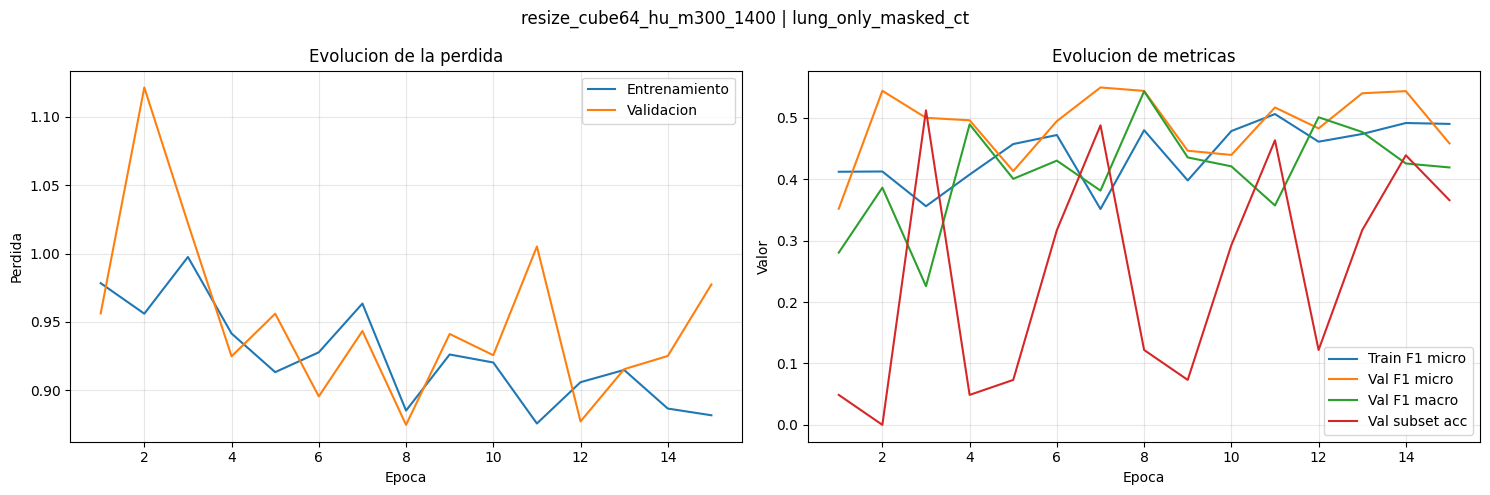

This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number 

[resize_cube64_hu_m300_1400 | nodule_only_masked_ct] epoch=01 train_loss=1.0086 val_loss=0.9704 val_f1_micro=0.3520 val_f1_macro=0.2805 subset=0.0488


This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


[resize_cube64_hu_m300_1400 | nodule_only_masked_ct] epoch=02 train_loss=0.9423 val_loss=0.9182 val_f1_micro=0.4034 val_f1_macro=0.3740 subset=0.0976


This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


...

[resize_cube64_hu_m300_1400 | nodule_only_masked_ct] epoch=16 train_loss=0.8888 val_loss=0.9246 val_f1_micro=0.5094 val_f1_macro=0.5027 subset=0.2927


This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


[resize_cube64_hu_m300_1400 | nodule_only_masked_ct] epoch=17 train_loss=0.8708 val_loss=0.9246 val_f1_micro=0.4074 val_f1_macro=0.4086 subset=0.1463


This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


[resize_cube64_hu_m300_1400 | nodule_only_masked_ct] epoch=18 train_loss=0.8666 val_loss=0.8870 val_f1_micro=0.4808 val_f1_macro=0.4824 subset=0.2439
Early stopping en epoca 18 para resize_cube64_hu_m300_1400 | nodule_only_masked_ct


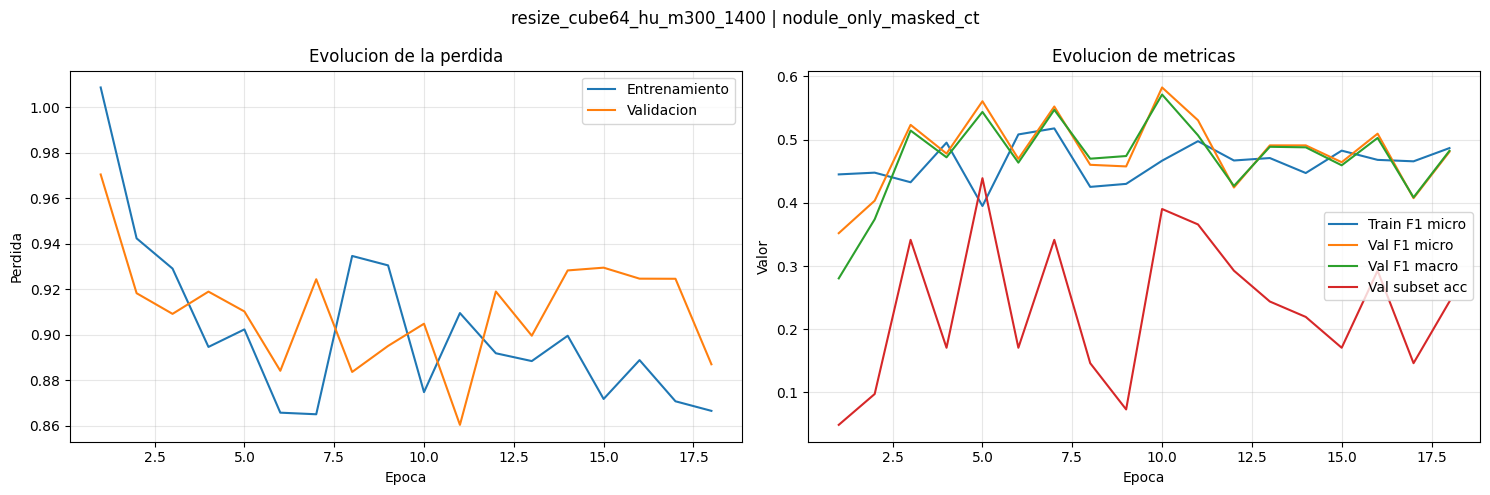

This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number 

[resize_cube64_hu_m300_1400 | ct_lung_nodule] epoch=01 train_loss=0.9880 val_loss=0.9704 val_f1_micro=0.4098 val_f1_macro=0.3810 subset=0.1220


This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


[resize_cube64_hu_m300_1400 | ct_lung_nodule] epoch=02 train_loss=0.9680 val_loss=0.9297 val_f1_micro=0.5472 val_f1_macro=0.4831 subset=0.2927


This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


...

[resize_cube64_hu_m300_1400 | ct_lung_nodule] epoch=08 train_loss=0.9051 val_loss=0.8090 val_f1_micro=0.5128 val_f1_macro=0.5146 subset=0.2439


This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


[resize_cube64_hu_m300_1400 | ct_lung_nodule] epoch=09 train_loss=0.8573 val_loss=0.8689 val_f1_micro=0.5439 val_f1_macro=0.5457 subset=0.2927


This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


[resize_cube64_hu_m300_1400 | ct_lung_nodule] epoch=10 train_loss=0.9033 val_loss=0.8902 val_f1_micro=0.4598 val_f1_macro=0.3852 subset=0.4146
Early stopping en epoca 10 para resize_cube64_hu_m300_1400 | ct_lung_nodule


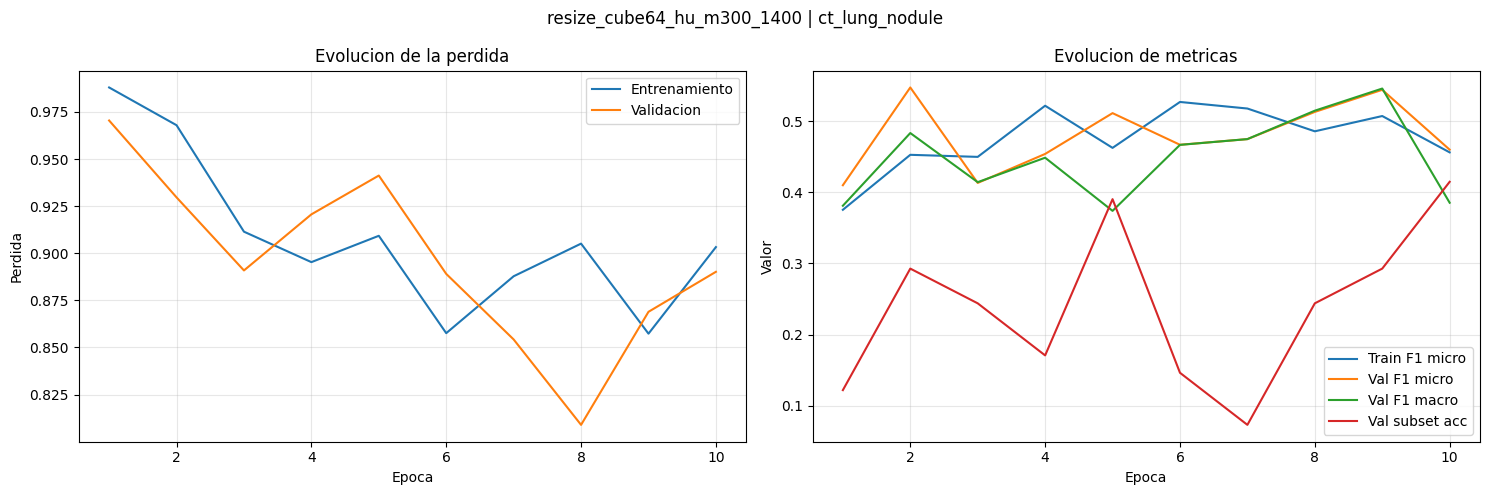

This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number 

[resize_cube64_hu_m300_1400 | nodule_vessels] epoch=01 train_loss=0.9453 val_loss=1.0091 val_f1_micro=0.3373 val_f1_macro=0.1970 subset=0.2927


This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


[resize_cube64_hu_m300_1400 | nodule_vessels] epoch=02 train_loss=0.9909 val_loss=0.9177 val_f1_micro=0.5234 val_f1_macro=0.4578 subset=0.2195


This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


...

[resize_cube64_hu_m300_1400 | nodule_vessels] epoch=09 train_loss=0.8859 val_loss=0.8381 val_f1_micro=0.5043 val_f1_macro=0.5104 subset=0.2439


This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


[resize_cube64_hu_m300_1400 | nodule_vessels] epoch=10 train_loss=0.8879 val_loss=0.8805 val_f1_micro=0.3918 val_f1_macro=0.3946 subset=0.2195


This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


[resize_cube64_hu_m300_1400 | nodule_vessels] epoch=11 train_loss=0.8945 val_loss=0.9060 val_f1_micro=0.4590 val_f1_macro=0.4564 subset=0.0488
Early stopping en epoca 11 para resize_cube64_hu_m300_1400 | nodule_vessels


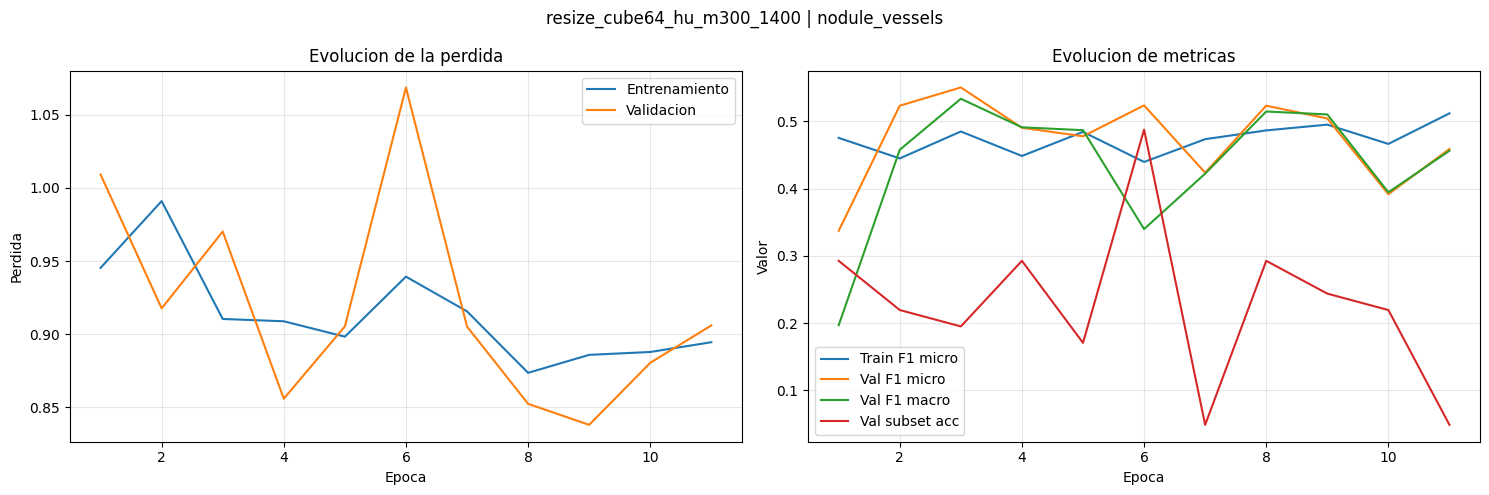

This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number 

[resize_cube64_hu_m300_1400 | ct_lung_nodule_vessels] epoch=01 train_loss=0.9504 val_loss=1.0801 val_f1_micro=0.3636 val_f1_macro=0.2933 subset=0.0732


This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


[resize_cube64_hu_m300_1400 | ct_lung_nodule_vessels] epoch=02 train_loss=0.9381 val_loss=0.9072 val_f1_micro=0.4792 val_f1_macro=0.4186 subset=0.3659


This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


...

[resize_cube64_hu_m300_1400 | ct_lung_nodule_vessels] epoch=12 train_loss=0.8203 val_loss=0.9225 val_f1_micro=0.4545 val_f1_macro=0.4457 subset=0.2195


This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


[resize_cube64_hu_m300_1400 | ct_lung_nodule_vessels] epoch=13 train_loss=0.8833 val_loss=0.9003 val_f1_micro=0.5000 val_f1_macro=0.4998 subset=0.2683


This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


[resize_cube64_hu_m300_1400 | ct_lung_nodule_vessels] epoch=14 train_loss=0.7971 val_loss=0.9491 val_f1_micro=0.4706 val_f1_macro=0.4663 subset=0.2683
Early stopping en epoca 14 para resize_cube64_hu_m300_1400 | ct_lung_nodule_vessels


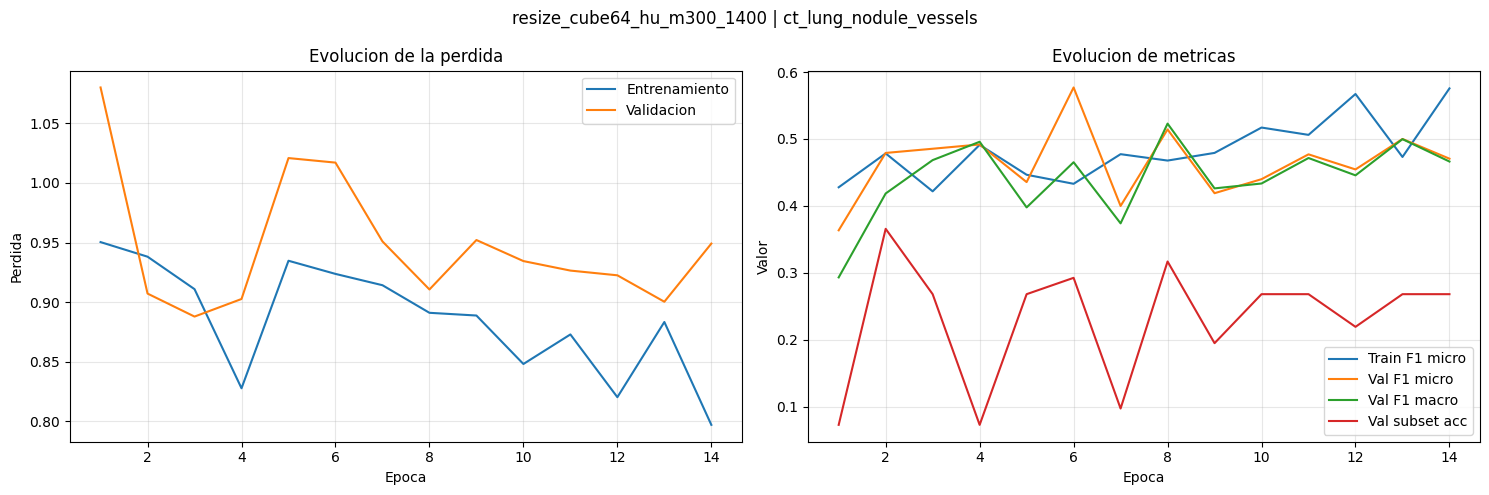

This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number 

[resize_cube64_hu_m300_1400 | weighted_lung_nodule_vessels] epoch=01 train_loss=0.9084 val_loss=1.0359 val_f1_micro=0.3520 val_f1_macro=0.2805 subset=0.0488


This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


[resize_cube64_hu_m300_1400 | weighted_lung_nodule_vessels] epoch=02 train_loss=0.9278 val_loss=0.9048 val_f1_micro=0.4144 val_f1_macro=0.3888 subset=0.1463


This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


...

[resize_cube64_hu_m300_1400 | weighted_lung_nodule_vessels] epoch=13 train_loss=0.8584 val_loss=0.8548 val_f1_micro=0.4528 val_f1_macro=0.4537 subset=0.2195


This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


[resize_cube64_hu_m300_1400 | weighted_lung_nodule_vessels] epoch=14 train_loss=0.8559 val_loss=0.8557 val_f1_micro=0.4865 val_f1_macro=0.4895 subset=0.2683


This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


[resize_cube64_hu_m300_1400 | weighted_lung_nodule_vessels] epoch=15 train_loss=0.8334 val_loss=0.8513 val_f1_micro=0.5133 val_f1_macro=0.5153 subset=0.2927
Early stopping en epoca 15 para resize_cube64_hu_m300_1400 | weighted_lung_nodule_vessels


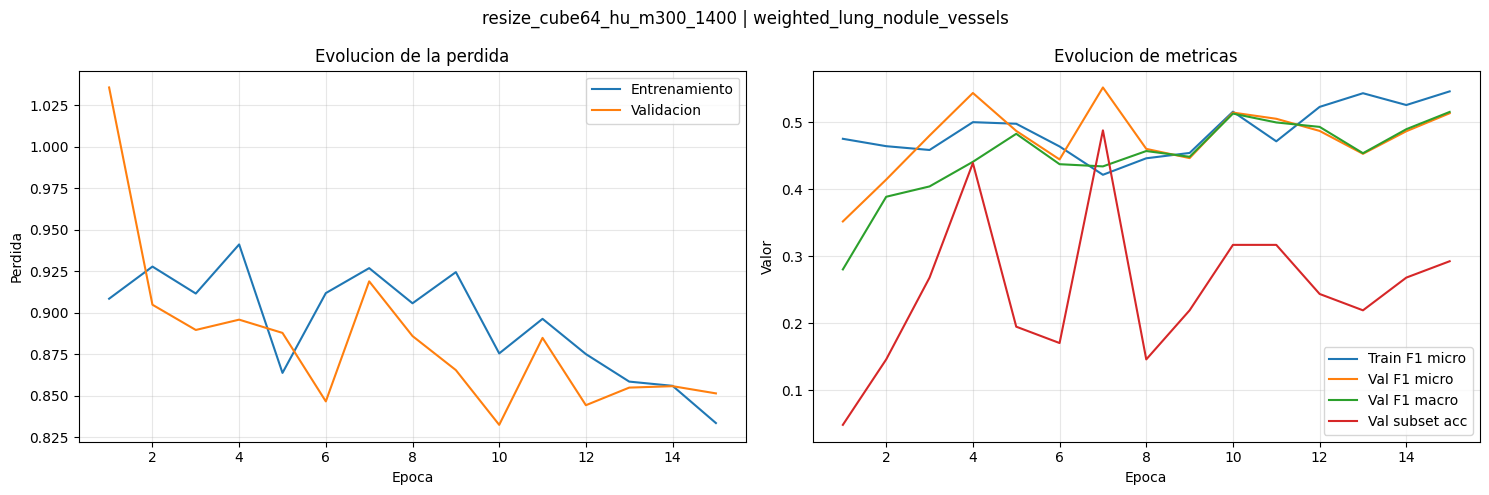

This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number 

[resize_cube64_hu_m600_1500 | lung_only_masked_ct] epoch=01 train_loss=0.9704 val_loss=0.9624 val_f1_micro=0.2247 val_f1_macro=0.1570 subset=0.1220


This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


[resize_cube64_hu_m600_1500 | lung_only_masked_ct] epoch=02 train_loss=0.9640 val_loss=1.1405 val_f1_micro=0.4486 val_f1_macro=0.3329 subset=0.0244


This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


...

[resize_cube64_hu_m600_1500 | lung_only_masked_ct] epoch=11 train_loss=0.8876 val_loss=0.9125 val_f1_micro=0.4587 val_f1_macro=0.4408 subset=0.1463


This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


[resize_cube64_hu_m600_1500 | lung_only_masked_ct] epoch=12 train_loss=0.8808 val_loss=0.8973 val_f1_micro=0.3762 val_f1_macro=0.3794 subset=0.2195


This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


[resize_cube64_hu_m600_1500 | lung_only_masked_ct] epoch=13 train_loss=0.8785 val_loss=0.9651 val_f1_micro=0.4138 val_f1_macro=0.3498 subset=0.3171
Early stopping en epoca 13 para resize_cube64_hu_m600_1500 | lung_only_masked_ct


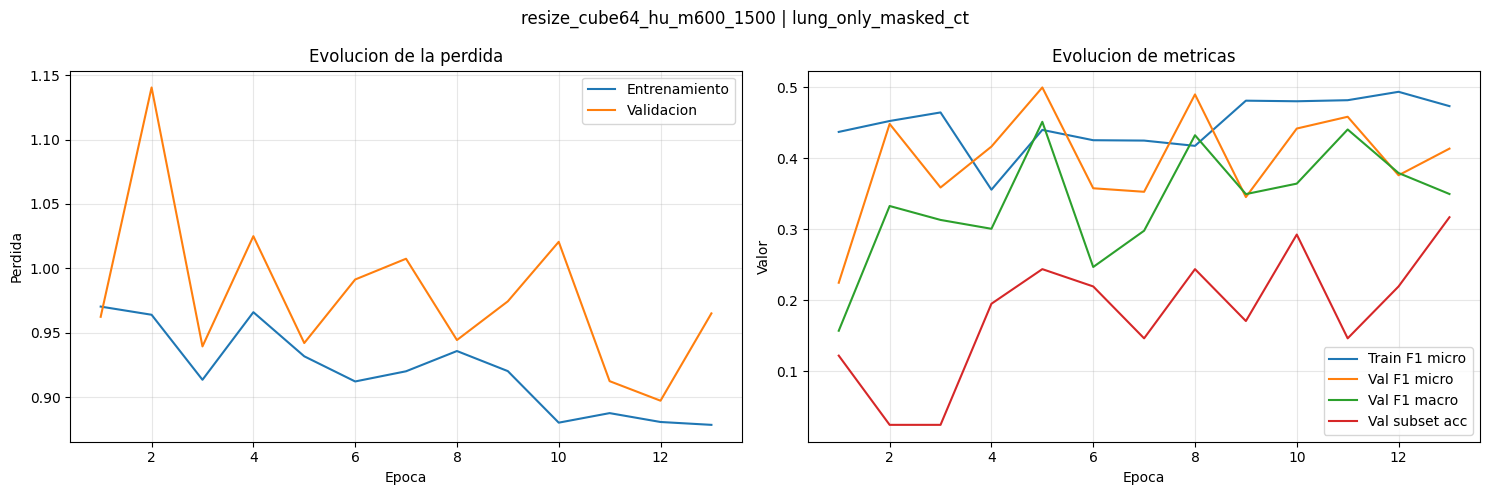

This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number 

[resize_cube64_hu_m600_1500 | nodule_only_masked_ct] epoch=01 train_loss=1.0210 val_loss=0.9784 val_f1_micro=0.4800 val_f1_macro=0.3458 subset=0.0000


This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


[resize_cube64_hu_m600_1500 | nodule_only_masked_ct] epoch=02 train_loss=0.9367 val_loss=1.0286 val_f1_micro=0.2745 val_f1_macro=0.2392 subset=0.0976


This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


...

[resize_cube64_hu_m600_1500 | nodule_only_masked_ct] epoch=09 train_loss=0.8777 val_loss=0.9291 val_f1_micro=0.4463 val_f1_macro=0.4419 subset=0.0732


This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


[resize_cube64_hu_m600_1500 | nodule_only_masked_ct] epoch=10 train_loss=0.8740 val_loss=0.8963 val_f1_micro=0.4571 val_f1_macro=0.4291 subset=0.3171


This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


[resize_cube64_hu_m600_1500 | nodule_only_masked_ct] epoch=11 train_loss=0.9103 val_loss=0.8629 val_f1_micro=0.5047 val_f1_macro=0.5030 subset=0.2927
Early stopping en epoca 11 para resize_cube64_hu_m600_1500 | nodule_only_masked_ct


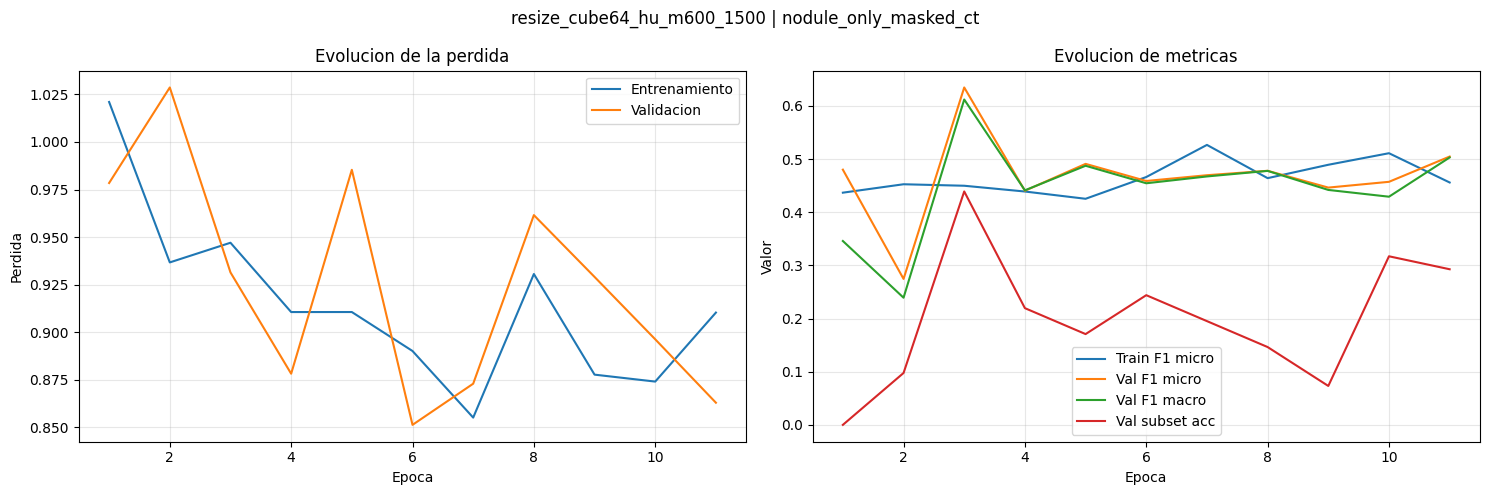

This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number 

[resize_cube64_hu_m600_1500 | ct_lung_nodule] epoch=01 train_loss=1.0015 val_loss=0.9289 val_f1_micro=0.2444 val_f1_macro=0.1694 subset=0.1220


This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


[resize_cube64_hu_m600_1500 | ct_lung_nodule] epoch=02 train_loss=0.9640 val_loss=1.0047 val_f1_micro=0.5794 val_f1_macro=0.4229 subset=0.2683


This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


...

[resize_cube64_hu_m600_1500 | ct_lung_nodule] epoch=08 train_loss=0.8928 val_loss=0.9139 val_f1_micro=0.4144 val_f1_macro=0.4237 subset=0.1951


This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


[resize_cube64_hu_m600_1500 | ct_lung_nodule] epoch=09 train_loss=0.8911 val_loss=0.8835 val_f1_micro=0.4696 val_f1_macro=0.4632 subset=0.2439


This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


[resize_cube64_hu_m600_1500 | ct_lung_nodule] epoch=10 train_loss=0.8588 val_loss=0.8773 val_f1_micro=0.4571 val_f1_macro=0.4510 subset=0.2195
Early stopping en epoca 10 para resize_cube64_hu_m600_1500 | ct_lung_nodule


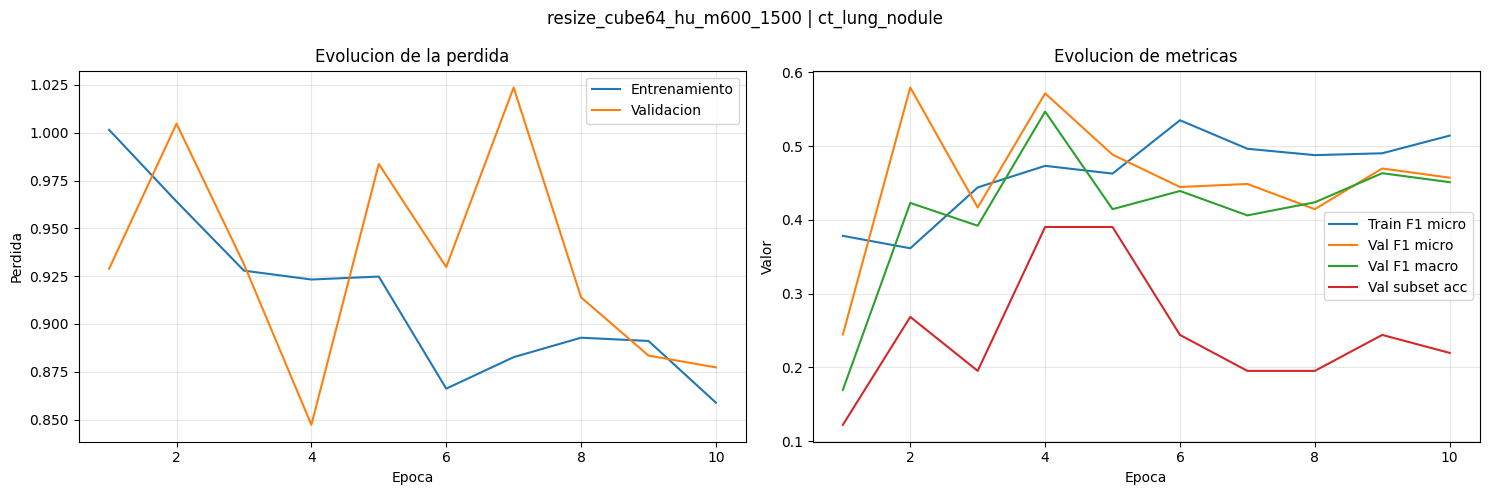

This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number 

[resize_cube64_hu_m600_1500 | nodule_vessels] epoch=01 train_loss=0.9731 val_loss=1.0442 val_f1_micro=0.2143 val_f1_macro=0.1200 subset=0.1707


This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


[resize_cube64_hu_m600_1500 | nodule_vessels] epoch=02 train_loss=0.9373 val_loss=0.9835 val_f1_micro=0.3542 val_f1_macro=0.3317 subset=0.1463


This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


...

[resize_cube64_hu_m600_1500 | nodule_vessels] epoch=16 train_loss=0.8261 val_loss=0.8981 val_f1_micro=0.4370 val_f1_macro=0.4244 subset=0.1463


This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


[resize_cube64_hu_m600_1500 | nodule_vessels] epoch=17 train_loss=0.8694 val_loss=0.8605 val_f1_micro=0.4815 val_f1_macro=0.4783 subset=0.2439


This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


[resize_cube64_hu_m600_1500 | nodule_vessels] epoch=18 train_loss=0.8412 val_loss=0.8267 val_f1_micro=0.5234 val_f1_macro=0.5276 subset=0.2927
Early stopping en epoca 18 para resize_cube64_hu_m600_1500 | nodule_vessels


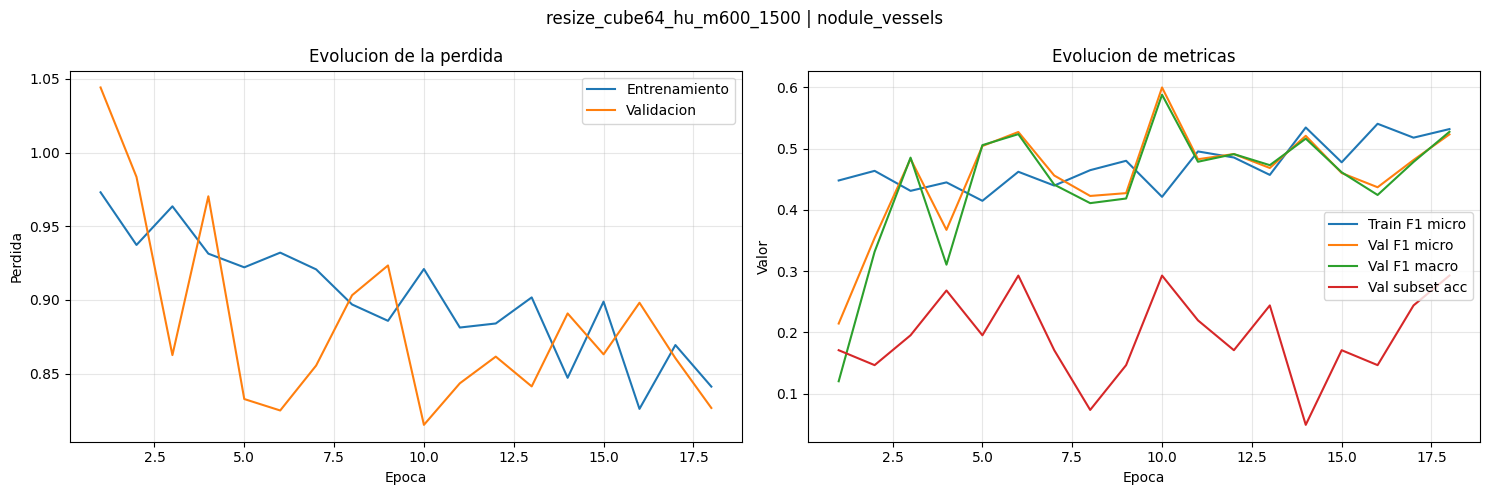

This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number 

[resize_cube64_hu_m600_1500 | ct_lung_nodule_vessels] epoch=01 train_loss=0.9466 val_loss=1.0487 val_f1_micro=0.3774 val_f1_macro=0.3315 subset=0.1220


This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


[resize_cube64_hu_m600_1500 | ct_lung_nodule_vessels] epoch=02 train_loss=0.9789 val_loss=0.9781 val_f1_micro=0.2151 val_f1_macro=0.2140 subset=0.1220


This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


...

This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


[resize_cube64_hu_m600_1500 | ct_lung_nodule_vessels] epoch=16 train_loss=0.8451 val_loss=0.9196 val_f1_micro=0.4421 val_f1_macro=0.4177 subset=0.3659


This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


[resize_cube64_hu_m600_1500 | ct_lung_nodule_vessels] epoch=17 train_loss=0.8300 val_loss=0.8103 val_f1_micro=0.5283 val_f1_macro=0.5338 subset=0.3415


This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


In [ ]:
all_summaries = []
all_histories = {}

for prep in selected_preprocs:
    for exp_cfg in selected_experiments:
        summary, history_df = run_single_experiment(prep, exp_cfg)
        all_summaries.append(summary)
        all_histories[(prep, exp_cfg["name"])] = history_df

summary_df = pd.DataFrame(all_summaries)
summary_df = summary_df.sort_values(["best_val_f1_micro", "val_f1_macro"], ascending=False).reset_index(drop=True)
summary_df.to_csv(RUN_ROOT / "summary_all_experiments.csv", index=False)
display(summary_df[[
    "preprocessing", "experiment", "best_epoch", "best_val_f1_micro", "val_f1_macro",
    "val_subset_accuracy", "val_hamming_loss", "val_precision_micro", "val_recall_micro"
]])

In [ ]:
plt.figure(figsize=(12, 5))
plot_df = summary_df.copy()
plot_df["run_name"] = plot_df["preprocessing"] + "\n" + plot_df["experiment"]
plt.bar(plot_df["run_name"], plot_df["best_val_f1_micro"])
plt.xticks(rotation=75, ha="right")
plt.ylabel("Best val F1 micro")
plt.title("Comparacion preliminar entre preprocesados y combinaciones de mascaras")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Siguientes pasos recomendados

Si alguna combinacion se comporta claramente mejor que las demas en este preliminar:
1. fijar las 2-3 variantes mas prometedoras
2. pasar a un script final con validacion cruzada a 5 folds
3. guardar predicciones out-of-fold y metricas por etiqueta
4. anadir despues la rama multimodal con variables clinicas

Si el comportamiento es inestable:
- bajar complejidad del espacio de entrada
- reducir el numero de canales
- probar solo `cube64` al principio
- ajustar `batch_size`, `patience` y `dropout`
- revisar si la etiqueta `Sin_complicacion` esta dominando el aprendizaje